# Module 08 — Visualization & animation

Every trajectory you have integrated so far ends the same way: as a `Trajectory`
object waiting to be *seen*. `tsdynamics` ships a backend-agnostic visualization
layer (`ts.viz`) built around a single idea — a **`PlotSpec`**, a declarative,
serializable description of a figure that renders itself on matplotlib, plotly,
or a data exporter. In this module we drive that layer end-to-end: single panels,
multi-panel composition, themes and styling, file export, and — the fun part —
**animation**, where an attractor sweeps out its geometry frame by frame.

**You will learn to:**
- render a `Trajectory` inline with `traj.plot(...)` and pick the right `PlotKind`
- build a savable `PlotSpec` with `traj.to_plot_spec(...)` and export `.png/.pdf/.svg/.html`
- compose figures with `ts.viz.plot(..., layout=...)` — overlay and multi-panel grids
- restyle and re-theme any spec fluently (`.style`, `.recolor`, `.theme`, `.style(axes=False)`)
- turn any spec into an animated **gif** with `to_plot_spec(animate=True)` and the
  chainable `.animate() / .trail() / .head() / .camera()` modifiers

*Estimated time: 30 min.*

In [1]:
# Colab/first-run setup: install the workshop stack if tsdynamics is missing.
try:
    import tsdynamics  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "tsdynamics[viz,interactive]==5.3.1", "matplotlib", "plotly", "pandas"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import tsdynamics as ts
print("tsdynamics", ts.__version__)

tsdynamics 5.3.1


In [2]:
# A tiny helper so every gif we make lands in the workshop's asset folder.
import os
IMG_DIR = "../assets/img"
os.makedirs(IMG_DIR, exist_ok=True)

## 1. Two front doors: `traj.plot(...)` vs `traj.to_plot_spec(...)`

There are two ways to draw a trajectory, and the distinction matters:

- **`traj.plot(...)`** eagerly renders with matplotlib and returns a `Figure`.
  In a notebook it **displays inline**. This is what you reach for when exploring.
- **`traj.to_plot_spec(...)`** returns a **`PlotSpec`** — a *description* of the
  plot, not a drawing. You can style it, compose it, and `.save(path)` it to any
  format. This is the object the rest of the module builds on.

Let's integrate the Lorenz system and look at it both ways.

In [3]:
lor = ts.Lorenz().integrate(final_time=40.0, dt=0.01)
print("Lorenz trajectory:", lor.y.shape, "samples of", lor.y.shape[1], "components")

# `traj.plot(...)` renders eagerly and returns the Figure. We echo the returned
# Figure as the last line of the cell so it embeds inline — that is how every
# plotting cell in this notebook ends.
fig = lor.to_plot_spec(kind="phase_portrait_3d", components=["x", "y", "z"],
                       color_by="time").plot()
fig.axes[0].set_title("Lorenz attractor — coloured by time")
fig

Lorenz trajectory: (4001, 3) samples of 3 components


<Figure size 640x480 with 2 Axes>

The `PlotKind` is auto-dispatched by how many components you select — 1 → time
series, 2 → 2-D portrait, 3 → 3-D portrait, 4+ → space-time image — but you can
always force it explicitly with `kind=`. Here the same trajectory, three ways:

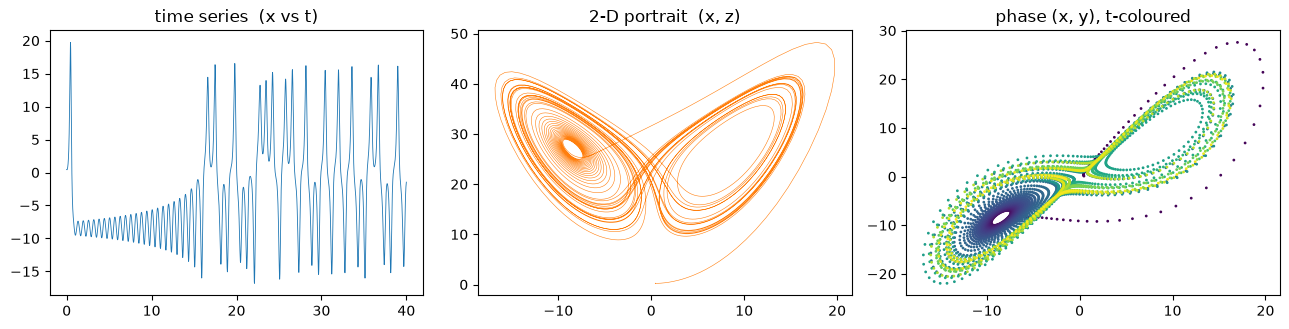

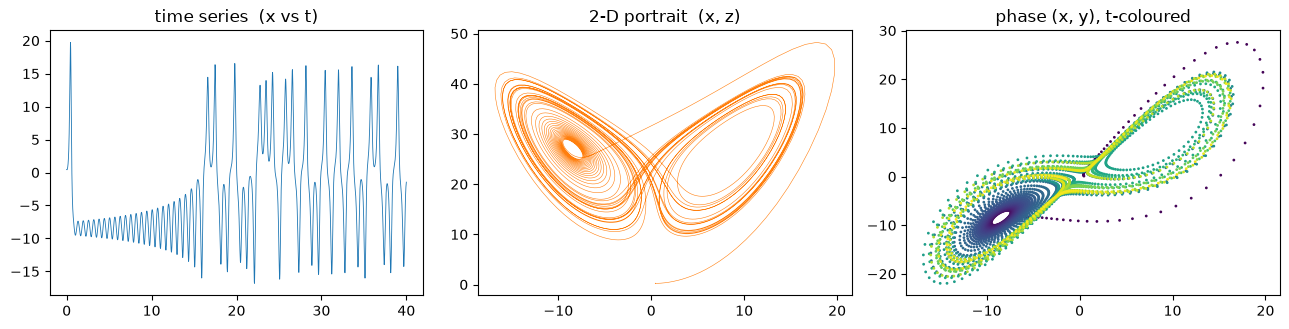

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
# Rebuild small panels by hand from the trajectory arrays for a compact overview.
axes[0].plot(lor.t, lor.y[:, 0], lw=0.6, color="C0"); axes[0].set_title("time series  (x vs t)")
axes[1].plot(lor.y[:, 0], lor.y[:, 2], lw=0.4, color="C1"); axes[1].set_title("2-D portrait  (x, z)")
axes[2].scatter(lor.y[:, 0], lor.y[:, 1], s=1, c=lor.t, cmap="viridis"); axes[2].set_title("phase (x, y), t-coloured")
for a in axes:
    a.set_xlabel("")
fig.tight_layout()
fig

The library's own `PlotKind` names (lowercase strings you pass to `kind=`) are:
`"time_series"`, `"phase_portrait_2d"`, `"phase_portrait_3d"`, `"spacetime"`,
plus two *recipes*: `"delay"` (an $x(t)$ vs $x(t-\tau)$ embedding, needs `tau=`)
and `"field"` (a spatial-field movie for PDE systems). Let's see the delay recipe —
a classic way to expose structure in a single scalar channel.

delay recipe -> PlotSpec


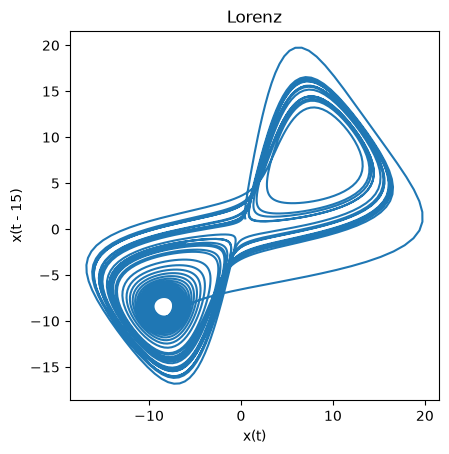

In [5]:
delay_spec = lor.to_plot_spec(kind="delay", components=["x"], tau=0.15)
print("delay recipe ->", type(delay_spec).__name__)
delay_spec.plot()  # PlotSpec.plot() returns a Figure, echoed below to embed it

For a **high-dimensional** system, three coordinates would be an arbitrary and
misleading slice. The `"spacetime"` kind instead images the *whole* state vector
as it evolves — one row per time step, one column per component. Lorenz-96
($\dot x_i = (x_{i+1}-x_{i-2})x_{i-1} - x_i + F$ on a ring of 20 sites) is a
natural fit: chaotic waves marching around the ring show up as diagonal streaks.

Lorenz-96: 20 coupled sites


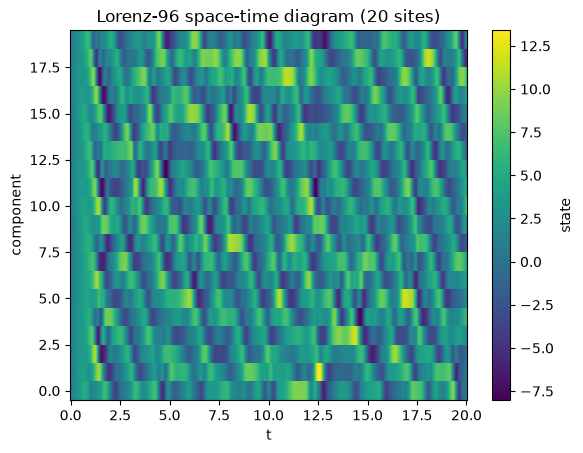

In [6]:
l96 = ts.Lorenz96().integrate(final_time=20.0, dt=0.05)
print("Lorenz-96:", l96.y.shape[1], "coupled sites")
fig = l96.to_plot_spec(kind="spacetime").plot()
fig.axes[0].set_title("Lorenz-96 space-time diagram (20 sites)")
fig

*The diagonal bands are travelling waves circling the ring; their breakup is the
spatiotemporal chaos this system is famous for.*

## 2. Composing figures: overlay and multi-panel

`ts.viz.plot(*things, layout=...)` is the figure-level front door. It converts
each argument (a trajectory, a system, a result, or a `PlotSpec`) to a panel and
returns a single composite `PlotSpec`:

- `layout="overlay"` — merge compatible panels onto **one** set of axes
- `layout="grid" / "stack" / "row"` — a genuine **multi-panel** figure

First, an **overlay**: two chaotic flows' $x(t)$ traces on shared axes. The
compose front door disambiguates the legend by source automatically.

overlay -> PlotSpec


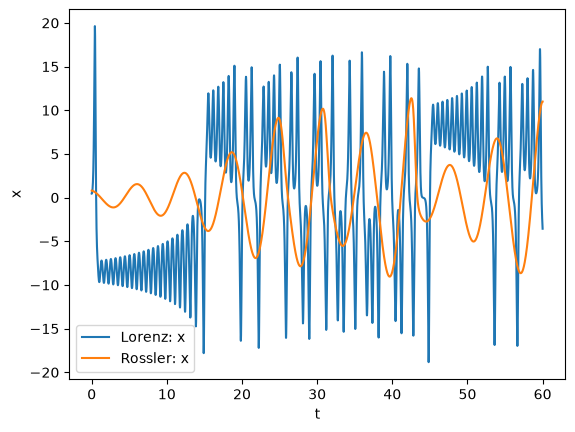

In [7]:
lor_short = ts.Lorenz().integrate(final_time=60.0, dt=0.01)
ross = ts.Rossler().integrate(final_time=60.0, dt=0.02)

overlay = ts.viz.plot(lor_short, ross, layout="overlay",
                      kind="time_series", components=["x"])
print("overlay ->", type(overlay).__name__)
overlay.plot()

Incompatible kinds (a 2-D portrait vs a 3-D one, or an image vs a line) refuse to
overlay — use a panelled layout instead. Here is a **2×2-style grid** of four
attractors, each drawn as its own panel:

grid composite -> PlotSpec


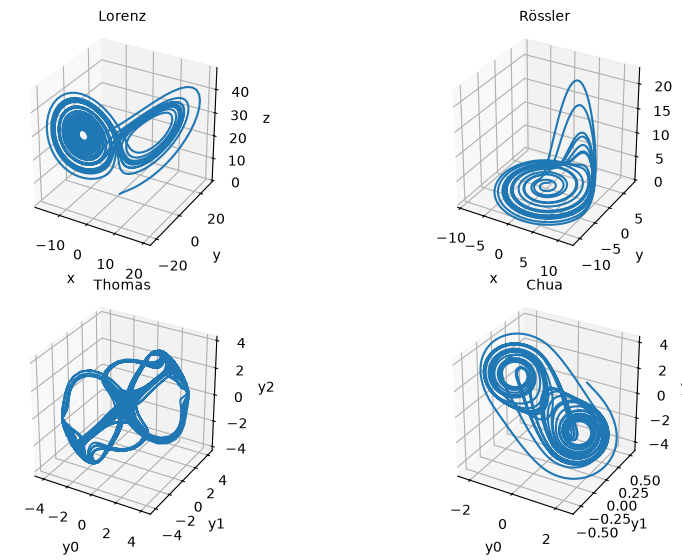

In [8]:
systems = [
    ("Lorenz", ts.Lorenz().integrate(final_time=30, dt=0.01)),
    ("Rössler", ts.Rossler().integrate(final_time=90, dt=0.02)),
    ("Thomas", ts.Thomas().integrate(final_time=150, dt=0.05)),
    ("Chua", ts.Chua().integrate(final_time=60, dt=0.02)),
]
panels = [tr.to_plot_spec(kind="phase_portrait_3d", components=[0, 1, 2]) for _, tr in systems]
grid = ts.viz.plot(*panels, layout="grid")
print("grid composite ->", type(grid).__name__)
fig = grid.plot()
for ax, (name, _) in zip(fig.axes, systems):
    ax.set_title(name, fontsize=10)
fig

*Four qualitatively different strange attractors, one call.* `layout="row"` and
`layout="stack"` give you a single row or a single column instead — pick whichever
fits the story. A composite `PlotSpec` is itself a `PlotSpec`, so you can nest
`ts.viz.plot(...)` calls to build arbitrarily structured figures.

## 3. Styling & themes

The look of every plot is controlled by one canonical, validated vocabulary,
applied identically across backends. The fluent tweaks all **mutate-and-return-self**,
so they chain:

- `.style(color=, linewidth=, alpha=, marker=, ...)` — per-layer style
- `.recolor(*colors)` — cycle new colours through the layers
- `.theme("dark"|"minimal"|"publication"|"default")` — a whole look
- `.style(axes=False)` — hide axes for a clean "floating attractor"

`ts.viz.themes()` lists the built-ins; `ts.viz.set_theme(name)` sets the global
default for every subsequent plot.

available themes: ['dark', 'default', 'minimal', 'publication']


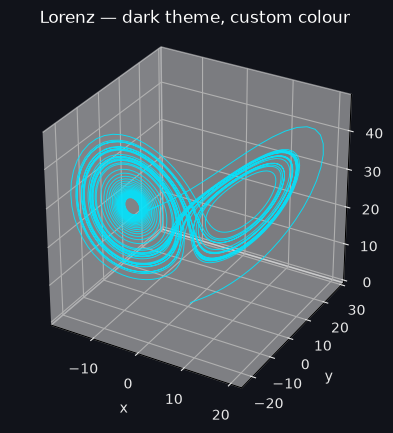

In [9]:
print("available themes:", ts.viz.themes())

styled = (
    lor.to_plot_spec(kind="phase_portrait_3d", components=["x", "y", "z"])
    .theme("dark")
    .style(color="#00e5ff", linewidth=0.7, alpha=0.9)
)
fig = styled.plot()
fig.axes[0].set_title("Lorenz — dark theme, custom colour", color="white")
fig

And the same attractor with the axes stripped away entirely — the geometry alone,
the way it often appears on a poster:

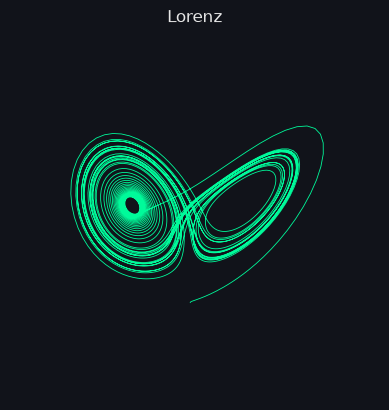

In [10]:
clean = (
    lor.to_plot_spec(kind="phase_portrait_3d", components=["x", "y", "z"])
    .theme("dark")
    .style(color="mediumspringgreen", linewidth=0.6)
    .style(axes=False)
)
clean.plot()

## 4. Saving to files

A `PlotSpec` renders itself to a file with `.save(path)`; the **extension picks
the backend**:

| extension | backend | notes |
|---|---|---|
| `.png` `.pdf` `.svg` | matplotlib | raster + vector, portable everywhere |
| `.html` | plotly | interactive, rotatable, self-contained page |
| `.gif` | matplotlib (pillow) | animation — always works, embeds in notebooks |
| `.mp4` | matplotlib (ffmpeg) | animation — needs ffmpeg |

Let's write a publication-themed vector PDF and a raster PNG, and confirm they
landed on disk.

In [11]:
pub = (
    ross.to_plot_spec(kind="phase_portrait_2d", components=[0, 1])
    .theme("publication")
    .style(color="darkslateblue", linewidth=0.8)
)
pub.save(f"{IMG_DIR}/rossler_xy.pdf")
pub.save(f"{IMG_DIR}/rossler_xy.png")
for ext in ("pdf", "png"):
    path = f"{IMG_DIR}/rossler_xy.{ext}"
    print(f"{ext}: {os.path.getsize(path):>7d} bytes  ->  {path}")

pdf:   21111 bytes  ->  ../assets/img/rossler_xy.pdf
png:   79992 bytes  ->  ../assets/img/rossler_xy.png


> **Interactive HTML.** `spec.save("orbit.html")` produces a self-contained plotly
> page you can rotate and zoom in a browser — great for sharing a 3-D attractor.
> We skip writing it here (plotly HTML files are several MB), but the call is the
> same one-liner. `spec.render(backend="plotly")` returns the live figure in a
> notebook. The library also ships `json` and `three.js` **data exporters** for
> embedding attractors in web pages.

## 5. Animation — the attractor in motion

Animation is an **orthogonal modifier**: any spec of any kind becomes a movie by
carrying an `Animation`. The semantic `kind` is unchanged; a backend that cannot
animate simply draws the final frame. You opt in with `to_plot_spec(animate=True)`,
then tune it with chainable modifiers:

- `.animate(fps=..., duration=..., loop=...)` — playback
- `.trail(("time", seconds) | ("steps", n) | None)` — comet-tail length
- `.head(show=True, size=..., color=...)` — the leading point
- `.camera(elev=, azim=, spin=True)` — orbit the 3-D camera while it plays

The **default frame model is `reveal`**: the full curve is kept and each frame
shows a comet — a bright head at the current sample, a tail reaching back
`trail_length`. We save a **gif** (portable, embeds in the notebook) into the
asset folder.

> **Compute note.** A gif's cost scales with its frame count (≈ one matplotlib
> render per sample). We keep frame counts near ~150 by integrating on a coarse
> grid — plenty for a smooth-looking loop, and it keeps this cell well inside the
> workshop's time budget.

In [12]:
from IPython.display import Image

# ~148 samples -> ~148 frames: a coarse grid keeps the gif small and fast.
lor_anim = ts.Lorenz().integrate(final_time=22.0, dt=0.15)
print("frames:", lor_anim.y.shape[0])

spec = (
    lor_anim.to_plot_spec(kind="phase_portrait_3d", components=["x", "y", "z"], animate=True)
    .animate(fps=20)
    .trail(("time", 6.0))   # comet tail spans 6 time units
    .head(show=True)
    .theme("dark")
    .style(color="deepskyblue", linewidth=0.9)
)
gif_path = f"{IMG_DIR}/lorenz_orbit.gif"
spec.save(gif_path, fps=20)
print(f"gif: {os.path.getsize(gif_path)/1e6:.2f} MB  ->  {gif_path}")

frames: 148


gif: 0.10 MB  ->  ../assets/img/lorenz_orbit.gif


And here it is, embedded and looping:

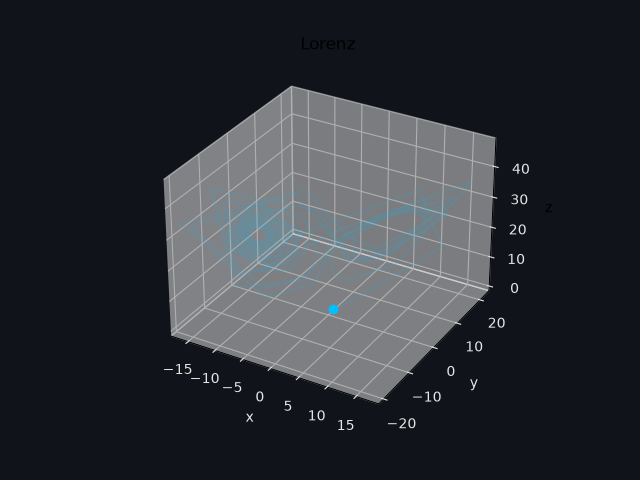

In [13]:
Image(filename=f"{IMG_DIR}/lorenz_orbit.gif")

*The comet traces one wing, jumps to the other, and never repeats — the animated
signature of a strange attractor.*

> **Other output formats.** The same spec saves to `.mp4` (`spec.save("x.mp4",
> fps=30)`, needs ffmpeg — present locally, sometimes absent on Colab) and to an
> `.html` plotly page that streams the comet in real time and lets you rotate the
> camera while it plays. For notebooks, `.gif` is the reliable, portable default.

## 🧪 Exercises

Fill in each starter cell (look for `# YOUR CODE HERE`). Worked answers follow in
the Solutions section — try first!

**Exercise 1 — Overlay two trajectories.**
Integrate `ts.Rossler()` from two *different* initial conditions (e.g. `ic=[1,1,0]`
and `ic=[1.01,1,0]`) for `final_time=60, dt=0.02`. Overlay their $x(t)$ time series
with `ts.viz.plot(a, b, layout="overlay", kind="time_series", components=["x"])`
and render inline. You should see the two curves track, then diverge — sensitive
dependence, made visible.

*Hint: pass `ic=` to `.integrate(...)`.*

In [14]:
# Exercise 1
a1 = ...  # first Rössler trajectory
b1 = ...  # second, nudged initial condition
# build the overlay spec and .plot() it
# YOUR CODE HERE

**Exercise 2 — A 2×2 grid of maps.**
Iterate four discrete maps — `ts.Henon()`, `ts.Ikeda()`, `ts.Tinkerbell()`,
`ts.Gingerbreadman()` — for `steps=3000` each, build a `phase_portrait_2d` spec
for each, and compose them with `layout="grid"`. Render inline and title each panel.

*Hint: `tr = ts.Henon().iterate(steps=3000, ic=[0.1, 0.1])` (these maps declare no
`default_ic`, so pass a safe on-attractor start); then
`tr.to_plot_spec(kind="phase_portrait_2d", components=[0, 1])`.*

In [15]:
# Exercise 2
map_names = ["Henon", "Ikeda", "Tinkerbell", "Gingerbreadman"]
# iterate each, build specs, compose with ts.viz.plot(*specs, layout="grid")
# YOUR CODE HERE

**Exercise 3 — Theme & style a figure.**
Take a `ts.Thomas()` trajectory (`final_time=150, dt=0.05`), build a 3-D phase
portrait spec, and apply the `"minimal"` theme plus a custom colour and linewidth
of your choice. Then make a *second* version with the axes hidden
(`.style(axes=False)`). Render both.

*Hint: chain `.theme("minimal").style(color=..., linewidth=...)`. Thomas declares
no `variables`, so select its components by index — `components=[0, 1, 2]`.*

In [16]:
# Exercise 3
thom = ts.Thomas().integrate(final_time=150.0, dt=0.05)
# make a themed+styled spec and a second axes-free spec, then .plot() both
# YOUR CODE HERE

**Exercise 4 — Animate a flow.**
Make a **gif** of the Rössler attractor. Integrate on a coarse grid
(`final_time=40, dt=0.25` → ~160 frames), build an animated `phase_portrait_3d`
spec, add a comet trail with `.trail(("time", 8.0))` and a head, save it to
`f"{IMG_DIR}/rossler_orbit.gif"` at `fps=20`, and display it with
`Image(filename=...)`.

*Hint: `to_plot_spec(..., animate=True).animate(fps=20).trail(("time", 8.0)).head(show=True)`.*

In [17]:
# Exercise 4
ross_anim = ...  # coarse-grid Rössler trajectory
# build the animated spec, save the gif, and display it inline
# YOUR CODE HERE

## ✅ Solutions

### Solution 1

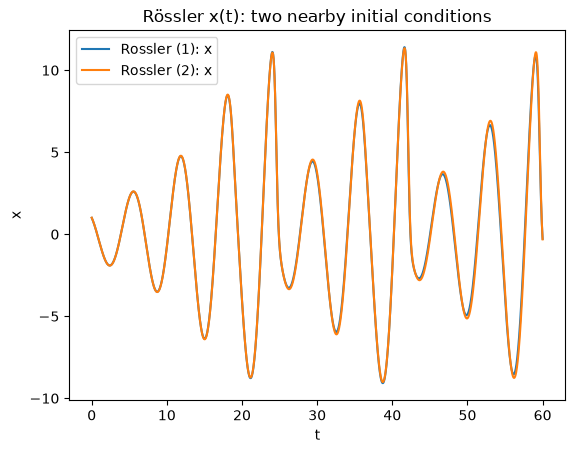

In [18]:
a1 = ts.Rossler().integrate(final_time=60.0, dt=0.02, ic=[1.0, 1.0, 0.0])
b1 = ts.Rossler().integrate(final_time=60.0, dt=0.02, ic=[1.01, 1.0, 0.0])

overlay1 = ts.viz.plot(a1, b1, layout="overlay", kind="time_series", components=["x"])
fig = overlay1.plot()
fig.axes[0].set_title("Rössler x(t): two nearby initial conditions")
fig

The two traces are indistinguishable early on and peel apart later — exactly the
exponential divergence we quantified as a positive Lyapunov exponent in Module 04.

### Solution 2

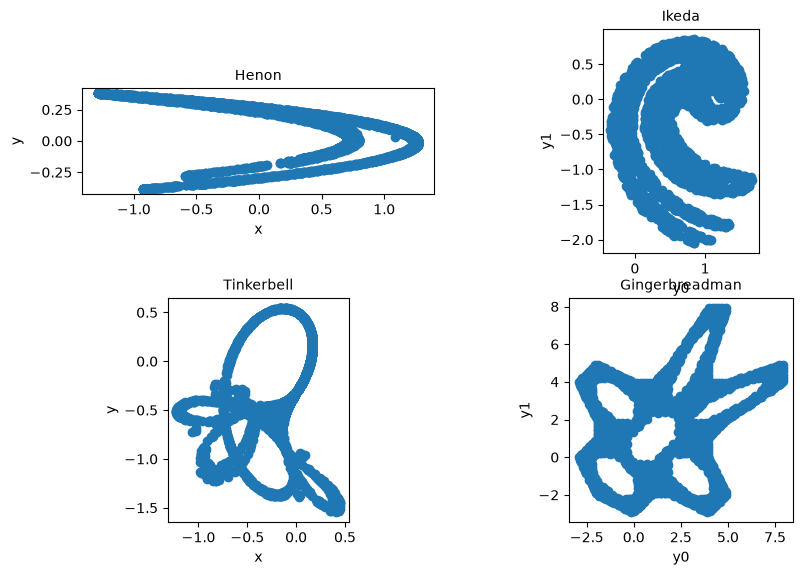

In [19]:
map_names = ["Henon", "Ikeda", "Tinkerbell", "Gingerbreadman"]
# These maps declare no default_ic, so pass a safe on-attractor ic explicitly —
# otherwise a random start can escape to infinity (an overflow warning).
map_ics = {
    "Henon": [0.1, 0.1],
    "Ikeda": [0.1, 0.1],
    "Tinkerbell": [-0.72, -0.64],
    "Gingerbreadman": [0.5, 3.7],
}
map_specs = []
for name in map_names:
    tr = getattr(ts, name)().iterate(steps=3000, ic=map_ics[name])
    map_specs.append(tr.to_plot_spec(kind="phase_portrait_2d", components=[0, 1]))

map_grid = ts.viz.plot(*map_specs, layout="grid")
fig = map_grid.plot()
for ax, name in zip(fig.axes, map_names):
    ax.set_title(name, fontsize=10)
fig

Four discrete maps, four distinct fractal geometries — the same compose front door
that stitched flows together handles maps identically.

### Solution 3

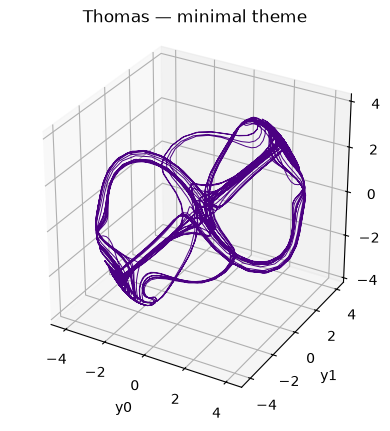

In [20]:
thom = ts.Thomas().integrate(final_time=150.0, dt=0.05)

# Thomas declares no `variables`, so we select components by index.
themed = (
    thom.to_plot_spec(kind="phase_portrait_3d", components=[0, 1, 2])
    .theme("minimal")
    .style(color="indigo", linewidth=0.7)
)
fig = themed.plot()
fig.axes[0].set_title("Thomas — minimal theme")
fig

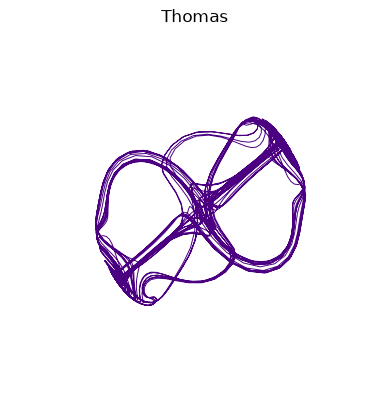

In [21]:
axfree = (
    thom.to_plot_spec(kind="phase_portrait_3d", components=[0, 1, 2])
    .theme("minimal")
    .style(color="indigo", linewidth=0.7)
    .style(axes=False)
)
axfree.plot()

Same data, two presentations: one annotated for a talk, one stripped to pure
geometry for a figure or logo.

### Solution 4

frames: 161


gif: 0.09 MB  ->  ../assets/img/rossler_orbit.gif


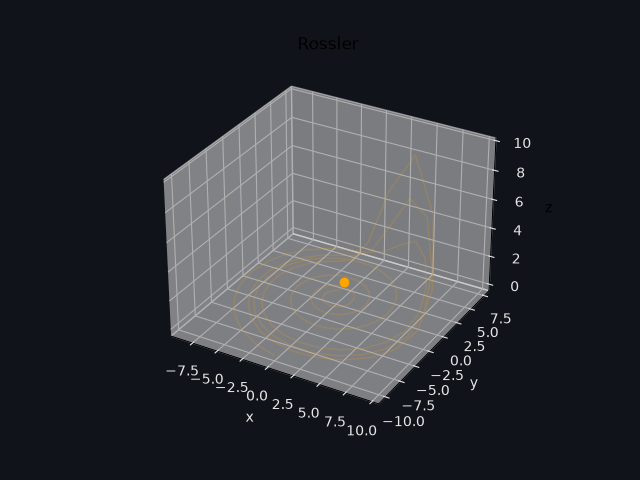

In [22]:
ross_anim = ts.Rossler().integrate(final_time=40.0, dt=0.25)
print("frames:", ross_anim.y.shape[0])

ross_spec = (
    ross_anim.to_plot_spec(kind="phase_portrait_3d", components=["x", "y", "z"], animate=True)
    .animate(fps=20)
    .trail(("time", 8.0))
    .head(show=True)
    .theme("dark")
    .style(color="orange", linewidth=0.9)
)
ross_gif = f"{IMG_DIR}/rossler_orbit.gif"
ross_spec.save(ross_gif, fps=20)
print(f"gif: {os.path.getsize(ross_gif)/1e6:.2f} MB  ->  {ross_gif}")
Image(filename=ross_gif)

The comet spirals out on the flat sheet, then folds up and over — the Rössler
"band-and-fold" mechanism, animated.

## Recap / Where next

You now command the `viz` layer:

- **`traj.plot(...)`** for quick inline exploration; **`traj.to_plot_spec(...)`**
  for a savable, composable `PlotSpec`.
- **PlotKinds** — time series, 2-D/3-D portraits, space-time images, and the
  `delay`/`field` recipes — auto-dispatched by component count or forced with `kind=`.
- **Composition** with `ts.viz.plot(..., layout="overlay"|"grid"|"stack"|"row")`,
  fully nestable (spec-in, spec-out).
- **Styling & themes** — fluent, chainable `.style / .recolor / .theme /
  .style(axes=False)`, honored identically across matplotlib and plotly.
- **Export** — `.png/.pdf/.svg` (matplotlib), `.html` (plotly interactive),
  `.gif/.mp4` (animation).
- **Animation** as an orthogonal modifier — `animate=True` plus `.animate / .trail /
  .head / .camera`, saved as a portable gif.

That closes the teaching arc. Everything we built — integration (Modules 01–02),
phase-space reduction (03), chaos quantifiers (04), time-series analysis (05),
stability (06), and basins & tipping (07) — comes together in the **capstone,
Module 09, "Guardian of the Grid"**, where you will *use* these plots and animations
to diagnose a power-grid model on the edge of collapse. See you there.